In [ ]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn --quiet

import pandas as pd

# Load the dataset
df = pd.read_csv('data.csv')

# Check for missing values
missing_data = df.isnull().sum()

# Print missing data summary
print("Missing Data Summary:")
print(missing_data)

# Handling Missing Data:
# For numerical columns, fill with appropriate values (mean, median, mode)
df['Engine HP'] = df['Engine HP'].fillna(df['Engine HP'].median())
df['Engine Cylinders'] = df['Engine Cylinders'].fillna(df['Engine Cylinders'].mean())

# For categorical columns, drop rows with missing values
df = df.dropna(subset=['Engine Fuel Type'])

Summary of Data Cleaning

Missing Value Identification: We checked each column in the dataset to identify which contain missing data.

Handling Missing Data:
For numerical columns (Engine HP and Engine Cylinders), we filled NaN values with the median/mean.
For categorical columns (Engine Fuel Type), we dropped rows where this column contained missing values.

This step is crucial for ensuring that our machine learning models are trained on a complete dataset, which can lead to better model performance and more accurate predictions.

In [ ]:
# Convert specific columns to appropriate data types
df['Year'] = df['Year'].astype(int)

# Verify the data types after conversion
print("Data Types After Conversion:")
print(df.dtypes)

Summary of Data Type Conversion

Conversion:
The 'Year' column was converted from a string to an integer using astype(int).

Verification:
We checked the data type of each column using dtypes after the conversion.

This ensures that the data is in a format suitable for machine learning algorithms, facilitating more accurate analysis and predictions.

In [ ]:
# Filter the dataset to include only cars from the year 1995 and later
filtered_df = df[df['Year'] >= 1995]

print("Filtered Data:")
print(filtered_df)

Summary of Data Filtering

Filtering:
We used boolean indexing to select rows where the 'Year' column values are greater than or equal to 1995.

Verification:
The filtered dataset contains only cars that meet the specified criteria.

This step is useful for focusing on a specific period of interest, allowing for further analysis and insights based on time-series data.

In [ ]:
# Convert the 'Vehicle Style' and 'Market Category' columns to lowercase
# Use .fillna('') to handle NaN values in Market Category before lowercasing
df['Vehicle Style'] = df['Vehicle Style'].str.lower()
df['Market Category'] = df['Market Category'].fillna('').str.lower()

print("DataFrame after String Operations:")
print(df)

Summary of String Operations

String Operations:
The 'Vehicle Style' and 'Market Category' columns were converted to lowercase using str.lower().

Verification:
We checked the data types of each column after the string operations to ensure that all text fields are now in lower case.

This step is important for consistency and simplifies the processing of text data for further analysis.

In [ ]:
# Create a new column for Total MPG
df['Total MPG'] = df['city mpg'] + df['highway MPG']

# Calculate Price per HP
df['Price per HP'] = df['MSRP'] / df['Engine HP']

print("DataFrame after Feature Engineering:")
print(df)

Summary of Feature Engineering

New Column Creation:
A new column called Total MPG was created by adding the 'City MPG' and 'Highway MPG' columns together.
A new column called Price per HP was calculated by dividing the 'MSRP' column by the 'Engine Power' column.

Verification:
We checked the data types of each column after feature engineering to ensure that all the required data is present and correctly calculated.

This step involves creating additional columns that can provide new insights into the dataset, such as a measure of fuel efficiency or the cost per horsepower.

In [ ]:
import numpy as np

# Calculate descriptive statistics for numerical columns
num_col_stats = df.describe(include=[np.number])

print("Descriptive Statistics of Numerical Columns:")
print(num_col_stats)

Summary of Exploratory Data Analysis (EDA) - Numerical Columns

Descriptive Statistics:
We calculated summary statistics for the numerical columns Engine HP, MSRP, Popularity, highway MPG, and city mpg.

Verification:
The descriptive statistics provide a quick overview of the distribution, central tendency, and spread of the data in each column.

This step helps to understand the basic characteristics of the dataset, which are crucial for further analysis and modeling.

In [ ]:
# Group the data by 'Driven_Wheels', 'Vehicle Size', and 'Engine Cylinders'
grouped_df = df.groupby(['Driven_Wheels', 'Vehicle Size', 'Engine Cylinders'])[['MSRP', 'Popularity']].mean()

print("Grouped Data by 'Driven_Wheels', 'Vehicle Size', and 'Engine Cylinders':")
print(grouped_df)

Summary of Grouped Data Analysis

Grouping:
We grouped the data by 'Driven_Wheels', 'Vehicle Size', and 'Engine Cylinders' and calculated the mean of 'MSRP' and 'Popularity'.

This helps to understand how vehicle characteristics affect price and popularity across different categories.

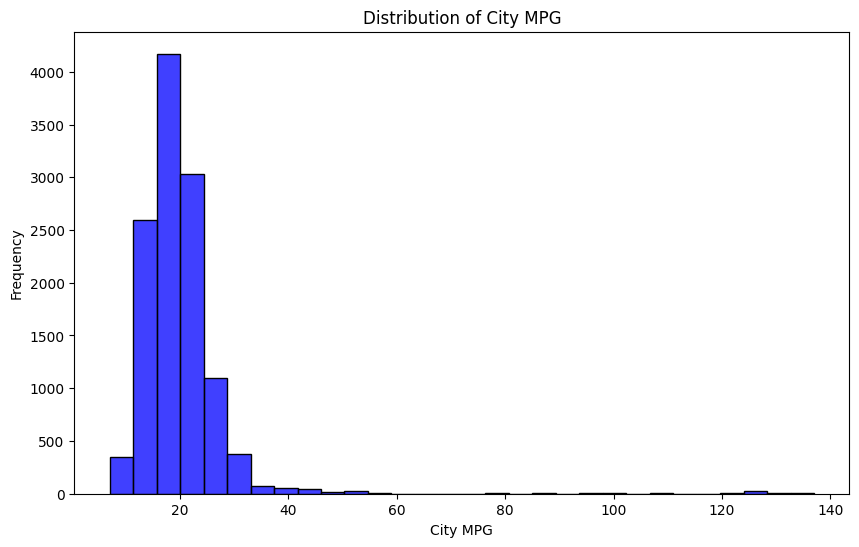

/var/folders/38/sjyl4bn11rsbfpfyqs6zgfgm0000gn/T/ipykernel_28818/2458423285.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Vehicle Size', y='MSRP', data=df, palette='viridis')


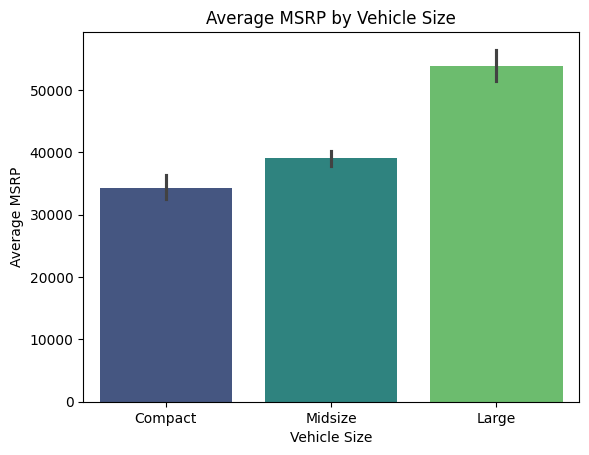

/var/folders/38/sjyl4bn11rsbfpfyqs6zgfgm0000gn/T/ipykernel_28818/2458423285.py:25: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='Engine HP', y='MSRP', data=df, palette='viridis')


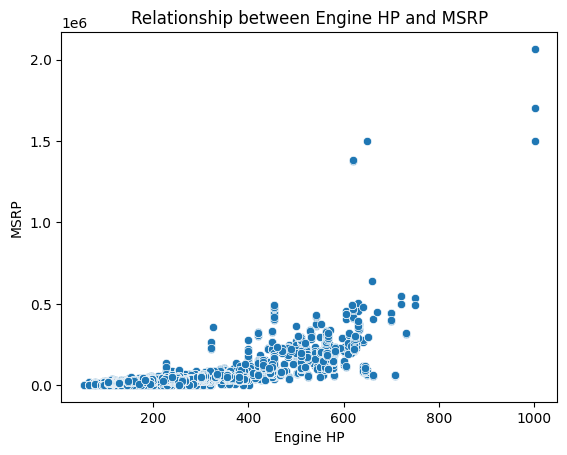

/var/folders/38/sjyl4bn11rsbfpfyqs6zgfgm0000gn/T/ipykernel_28818/2458423285.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Driven_Wheels', y='MSRP', data=df, palette='viridis')


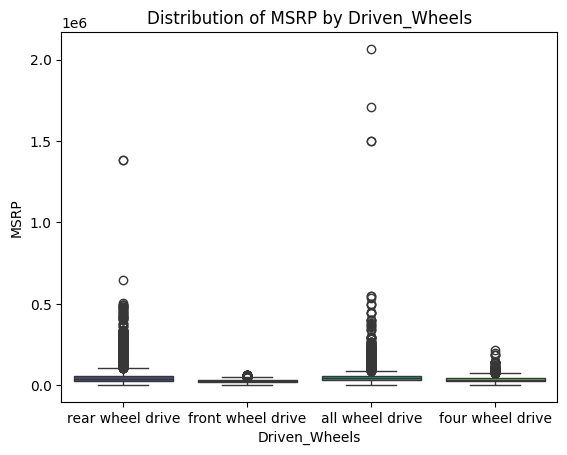

In [15]:
import sys
!{sys.executable} -m pip install matplotlib seaborn --quiet

import matplotlib.pyplot as plt
import seaborn as sns

# Create a histogram of city mpg
plt.figure(figsize=(10, 6))
sns.histplot(df['city mpg'], bins=30, color='blue', edgecolor='black')
plt.title('Distribution of City MPG')
plt.xlabel('City MPG')
plt.ylabel('Frequency')
plt.show()

# Create a bar chart of average MSRP by Vehicle Size
fig, ax = plt.subplots()
sns.barplot(x='Vehicle Size', y='MSRP', data=df, palette='viridis')
ax.set_title('Average MSRP by Vehicle Size')
ax.set_xlabel('Vehicle Size')
ax.set_ylabel('Average MSRP')
plt.show()

# Create a scatter plot of Engine HP vs. MSRP
fig, ax = plt.subplots()
sns.scatterplot(x='Engine HP', y='MSRP', data=df, palette='viridis')
plt.title('Relationship between Engine HP and MSRP')
plt.xlabel('Engine HP')
plt.ylabel('MSRP')
plt.show()

# Create a boxplot of MSRP by Driven_Wheels
fig, ax = plt.subplots()
sns.boxplot(x='Driven_Wheels', y='MSRP', data=df, palette='viridis')
plt.title('Distribution of MSRP by Driven_Wheels')
plt.xlabel('Driven_Wheels')
plt.ylabel('MSRP')
plt.show()

Summary of Visualizations

Histogram:
A histogram was created to visualize the distribution of the 'City MPG' column.

Bar Chart:
A bar chart was generated to show the average 'MSRP' for each category in the Vehicle Size feature.

Scatter Plot:
A scatter plot was plotted to demonstrate the relationship between 'Engine HP' and 'MSRP'.

Boxplot:
A boxplot was created to visualize the distribution of 'MSRP' for each combination in the Driven_Wheels feature.

These visualizations provide insights into different aspects of the dataset, which can be used for further analysis, trend identification, and decision-making.

Correlation Matrix:
                      Year  Engine HP  Engine Cylinders  Number of Doors  \
Year              1.000000   0.350454         -0.041405         0.263960   
Engine HP         0.350454   1.000000          0.767448        -0.103023   
Engine Cylinders -0.041405   0.767448          1.000000        -0.140019   
Number of Doors   0.263960  -0.103023         -0.140019         1.000000   
highway MPG       0.258225  -0.359533         -0.602291         0.118607   
city mpg          0.198126  -0.353997         -0.566973         0.120938   
Popularity        0.072903   0.036666          0.041167        -0.048158   
MSRP              0.227536   0.661396          0.531303        -0.126585   

                  highway MPG  city mpg  Popularity      MSRP  
Year                 0.258225  0.198126    0.072903  0.227536  
Engine HP           -0.359533 -0.353997    0.036666  0.661396  
Engine Cylinders    -0.602291 -0.566973    0.041167  0.531303  
Number of Doors      0.118607  0.120938

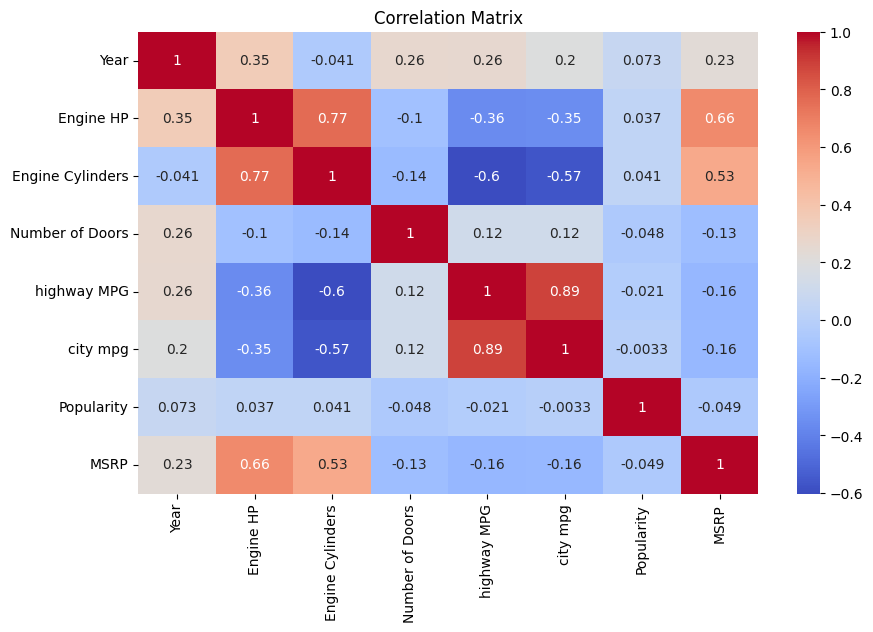

In [17]:
import seaborn as sns

# Calculate correlations among all numerical columns
correlation_matrix = df.corr(numeric_only=True)

print("Correlation Matrix:")
print(correlation_matrix)

# Create a heatmap of the correlation matrix
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

Summary of Correlation Analysis

Correlation Calculation:
We calculated the correlations among all numerical columns in the dataset using df.corr().

Heatmap:
A heatmap was generated to visualize the correlation matrix.

Verification:
The correlation matrix provides a clear picture of how different variables are related to each other.

This step is crucial for understanding the relationships between the various features, which can be used for feature selection or improving the predictive power of the models.